In [3]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from ModelTraining.Model import MotionPointTransformer  # Your model class

class PointImportanceWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.transformer_output = None  # Store output from transformer
        self.model.transformer.register_forward_hook(self._hook_transformer)

    def _hook_transformer(self, module, input, output):
        self.transformer_output = output  # [B, N+1, dim]

    def forward(self, x):
        return self.model(x)

In [54]:
model = MotionPointTransformer(num_classes=47)
model.load_state_dict(torch.load("saved_models/model_epoch_100_acc_90.05.pt"))  # Put correct path
model.eval().cpu()

wrapped_model = PointImportanceWrapper(model).cpu()

data = torch.load("/Users/mrinalraj/Downloads/WebDownload/Driving48/videosTensors1000/l6ZoMjD1UtA_00001_tracking.pt")
pred_tracks = data['pred_tracks']  # shape: [1000, T, 3]
input_tensor = pred_tracks.unsqueeze(0).float().to("cpu")  # [1, 1000, T, 3]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [56]:
from torch.utils.data import DataLoader
from ModelTraining.DataLoader import MotionDataset
import pandas as pd
# Load dataset
test_df = pd.DataFrame([{
    "vid_name": "l6ZoMjD1UtA_00001",  # match this to filename logic
    "label": 35  # dummy label if needed
}])
PT_FOLDER = "./videosTensors1000/"
dataset = MotionDataset(test_df, PT_FOLDER)
print(dataset)
# Fetch sample
input_tensor, label, name = dataset[0]
input_tensor = input_tensor.unsqueeze(0).float().to("cpu")
print(input_tensor.shape, label, name)

torch.Size([1, 101, 1000, 3]) tensor(35) l6ZoMjD1UtA_00001


In [24]:
class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        x.requires_grad_(True)  # Enable gradient computation on input
        self.input_tensor = x   # Save for access later
        return self.model(x)

wrapped_model = WrappedModel(model)

In [25]:
output = wrapped_model(input_tensor)  # input_tensor: [1, 1000, T, 3]
true_label = 42
wrapped_model.model.zero_grad()
output[0, true_label].backward()

# === Access input gradients ===
input_grads = wrapped_model.input_tensor.grad.detach()  # [1, 1000, T, 3]
grads_per_point = input_grads.pow(2).sum(dim=(2, 3))[0]  # [1000]

# === Get top-20 important points ===
topk = 20
top_indices = torch.topk(grads_per_point, k=topk).indices.cpu().tolist()
print(f"Top-{topk} important point indices:", top_indices)


Top-20 important point indices: [1, 69, 80, 0, 9, 78, 62, 64, 67, 44, 3, 11, 18, 15, 24, 29, 59, 6, 43, 23]


In [23]:
output = wrapped_model(input_tensor)
wrapped_model.model.zero_grad()
output[0, pred_class].backward()

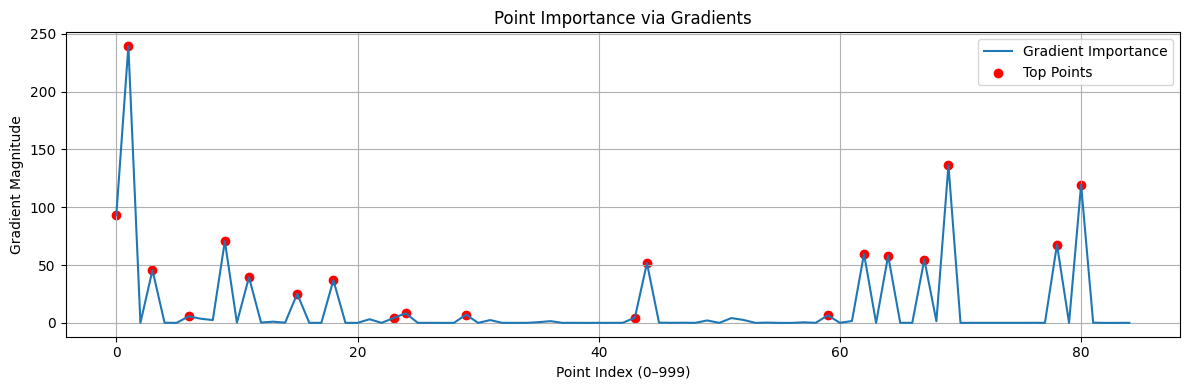

In [26]:
# === Optional: Visualize importance scores ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(grads_per_point.cpu().numpy(), label="Gradient Importance")
plt.scatter(top_indices, grads_per_point[top_indices].cpu().numpy(), color='red', label="Top Points")
plt.title("Point Importance via Gradients")
plt.xlabel("Point Index (0–999)")
plt.ylabel("Gradient Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("top_points_gradients.png")
plt.show()

In [70]:
print(input_tensor.shape)

torch.Size([1, 101, 1000, 3])


In [96]:
# ========================= Grad-CAM Hook Functions ========================= #
def register_hooks(model):
    grads = {}
    acts = {}

    def forward_hook(module, input, output):
        acts["val"] = output.detach()

    def backward_hook(module, grad_input, grad_output):
        grads["val"] = grad_output[0].detach()

    h1 = model.transformer.register_forward_hook(forward_hook)
    h2 = model.transformer.register_full_backward_hook(backward_hook)
    return grads, acts, (h1, h2)

def compute_point_importance(model, input_tensor, label):
    grads, acts, hooks = register_hooks(model)
    input_tensor.requires_grad = True
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, pred_class].backward()

    grad = grads["val"]  # [B, N+1, D]
    act = acts["val"]    # [B, N+1, D]

    weights = grad.mean(dim=2)  # [B, N+1]
    cam = (weights.unsqueeze(2) * act).sum(dim=2)  # [B, N+1]
    cam = cam[0, 1:]  # exclude cls token
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-5)  # normalize

    for h in hooks:
        h.remove()

    return cam  # shape [1000]


In [102]:
# ========================= Save Frames with Top-K Points ========================= #
def save_topK_frames(input_tensor, scores, name, output_folder, top_k=100):
    os.makedirs(output_folder, exist_ok=True)
    _, N, T, _ = input_tensor.shape
    print(_, N, T, _)
    coords = input_tensor[0, :, :, :2].detach().cpu().numpy()  # [1000, T, 2]
    coords = coords.transpose(1, 0, 2)  # [T, 1000, 2]
    print(f"{coords.shape}")
    top_indices = torch.topk(scores, k=top_k).indices.cpu().tolist()

    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(top_k)]

    for t in range(T):
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.invert_yaxis()

        for i, pt_id in enumerate(top_indices):
            x, y = coords[t, pt_id]
            ax.scatter(x, y, color=colors[i % 20], s=40)

        ax.set_title(f"Top-{top_k} Points | Frame {t}")
        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, f"frame_{t:04d}.png"))
        plt.close()

In [98]:
# ========================= Make Video from Frames ========================= #
def make_video_from_frames(frame_folder, output_path, fps=10):
    frame_files = sorted([f for f in os.listdir(frame_folder) if f.endswith(".png")])
    if not frame_files:
        raise ValueError("No frames found in folder.")

    first_frame = cv2.imread(os.path.join(frame_folder, frame_files[0]))
    H, W, _ = first_frame.shape

    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    for fname in frame_files:
        frame = cv2.imread(os.path.join(frame_folder, fname))
        writer.write(frame)
    writer.release()
    print(f"✅ Saved video to {output_path}")


3 101 1000 3
(1000, 101, 2)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x104550980>>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

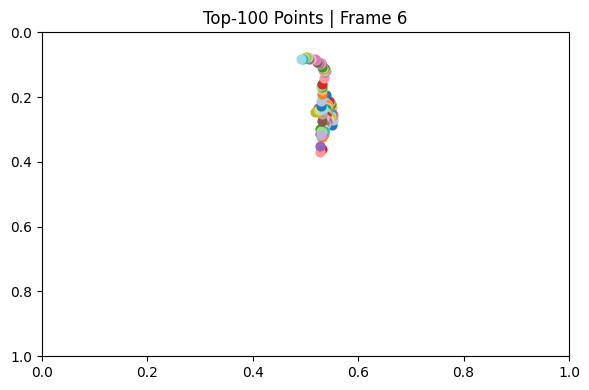

In [103]:

# Compute scores and extract top-100 points
gradcam_scores = compute_point_importance(model, input_tensor, label)
frame_dir = f"frames_top100_{name}"
video_path = f"video_top100_{name}.mp4"

# Save frames and video
save_topK_frames(input_tensor, gradcam_scores, name, frame_dir, top_k=100)
make_video_from_frames(frame_dir, video_path)


In [2]:
import torch

checkpoint = torch.load("Users/mrinalraj/Downloads/WebDownload/Driving48/saved_models_model1/model_epoch_96_acc_90.79.pt", map_location='cpu')
print(type(checkpoint))

ModuleNotFoundError: No module named 'torch'